In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.transforms as mtransforms
from matplotlib.patches import FancyBboxPatch

In [ ]:
pnoe_df = pd.read_csv('data/pnoe_data.csv', delimiter=';')
spirometry_df = pd.read_csv('data/spirometry_data.csv')

In [ ]:
df = pnoe_df.apply(pd.to_numeric, errors='ignore')
df['VO2 Pulse'] = df['VO2(ml/min)'] / df['HR(bpm)']  # VO2 Pulse in mL/beat
df['VO2 Breath'] = df['VO2(ml/min)'] / df['BF(bpm)']  # VO2 per Breath in mL/breath
df['CHO'] = df['EE(kcal/min)'] * df['CARBS(%)']/100
df['FAT'] = df['EE(kcal/min)'] * df['FAT(%)']/100
# Smooth key columns using rolling window
window_size = 10

# List of columns to smooth
columns_to_smooth = ['VO2(ml/min)', 'VCO2(ml/min)', 'HR(bpm)', 'VT(l)', 'BF(bpm)', 'VE(l/min)', 'VO2 Pulse', 'VO2 Breath', 'CHO', 'FAT']

# Apply smoothing to each column
for col in columns_to_smooth:
    if col in df.columns:
        df[f'{col}_smoothed'] = df[col].rolling(window=window_size, min_periods=1).mean()

,T(sec),PHASE,HR(bpm),VO2(ml/min),VCO2(ml/min),RER,VE(l/min),FEO2,FECO2,FETO2,...,EE(kcal/min),CARBS(kcal),CARBS(%),FAT(kcal),FAT(%),MET,CUMULATIVE EE(kcal),BP(kPa),Watts,Speed
0,3.0,NaN,64.0,225.40,204.22,0.91,8.29,0.1751,0.0352,0,...,0.00,0.00,0.00,0.00,0.00,1.19,0.00,99.46,0.0,0.0
1,8.0,NaN,62.0,383.07,382.56,1.00,14.36,0.1769,0.0350,0,...,1.91,0.16,99.55,0.00,0.45,2.03,0.16,99.46,0.0,0.0
2,12.0,NaN,62.0,310.11,298.57,0.96,11.56,0.1765,0.0349,0,...,1.54,0.09,87.60,0.01,12.40,1.64,0.26,99.46,0.0,0.0
3,14.0,NaN,61.0,296.31,293.30,0.99,11.12,0.1778,0.0351,0,...,1.48,0.05,96.61,0.00,3.39,1.57,0.31,99.46,0.0,0.0
4,17.0,NaN,60.0,189.86,175.37,0.92,7.32,0.1772,0.0328,0,...,0.93,0.03,74.56,0.01,25.44,1.00,0.36,99.46,0.0,0.0


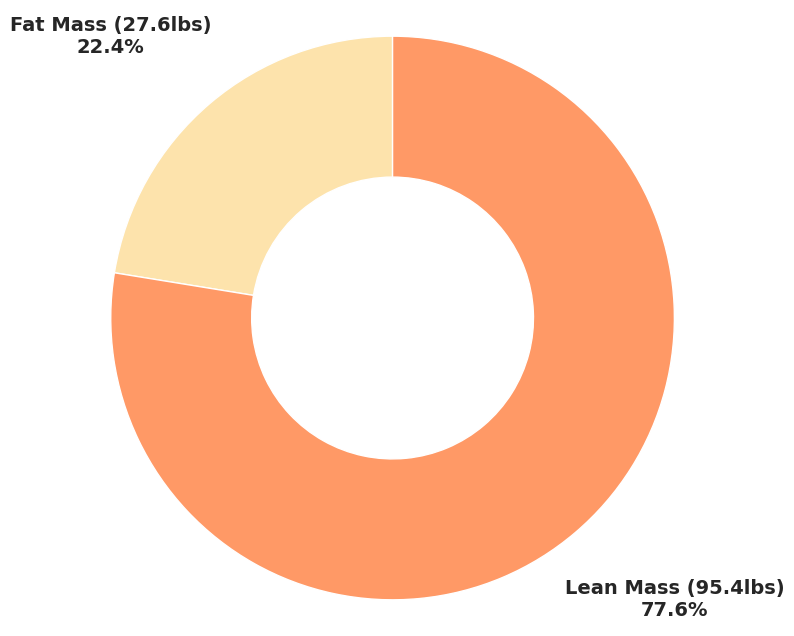

In [ ]:
def body_composition_chart(fat_percentage=22.4, weight_kg=70):

    
    #=========================== Body Composition Donut Chart ========================#
    lean_percentage = 100 - fat_percentage

# Create donut chart
    fat_mass_lbs = weight_kg * (fat_percentage / 100) * 2.20462
    lean_mass_lbs = weight_kg * (lean_percentage / 100) * 2.20462

# Calculate percentages from the provided weights
    total_weight = fat_mass_lbs + lean_mass_lbs
    fat_percentage = (fat_mass_lbs / total_weight) * 100
    lean_percentage = (lean_mass_lbs / total_weight) * 100

# Data for the chart
    sizes = [fat_percentage, lean_percentage]
    colors = ['#fde3ac', '#ff9966'] # Light yellow/tan and orange from the image

    plt.figure(figsize=(8, 8))

# Create the donut chart without labels first
    wedges, texts, autotexts = plt.pie(sizes,
                                    autopct='',  # Remove auto percentages
                                    startangle=90,
                                    wedgeprops=dict(width=0.5, edgecolor='w'),
                                    colors=colors,
                                    labels=['', ''])  # Remove default labels

# Add custom text annotations positioned manually
    plt.text(-1, 1, f'Fat Mass ({fat_mass_lbs:.1f}lbs)\n{fat_percentage:.1f}%', 
            fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

    plt.text(1, -1, f'Lean Mass ({lean_mass_lbs:.1f}lbs)\n{lean_percentage:.1f}%', 
            fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Set the title
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
    # plt.savefig('graphs/body_composition_chart.png', bbox_inches='tight', dpi=600)
    plt.show()

# Set a common style
    sns.set_theme(style="whitegrid")


body_composition_chart()

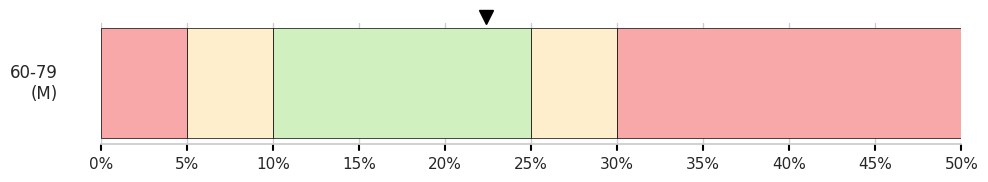

In [15]:
def body_fat_percentage_chart(gender='female', age=25, fat_percentage=22.4):
    """
    Creates a body fat percentage bar chart based on gender and age group.
    
    Parameters:
    - gender: 'male' or 'female'
    - age: age of the person
    - fat_percentage: body fat percentage value
    """
    
    # Determine age group
    if age >= 20 and age <= 39:
        age_group = "20-39"
    elif age >= 40 and age <= 59:
        age_group = "40-59"
    elif age >= 60 and age <= 79:
        age_group = "60-79"
    else:
        print(f"Age {age} is outside the supported range (20-79)")
        return
    
    # Normalize gender input
    gender = gender.lower()
    if gender not in ['male', 'female']:
        print("Gender must be 'male' or 'female'")
        return
    
    # Define segments based on gender and age group
    if gender == 'female':
        if age_group == "20-39":
            segments = [
                ('#F8A8A8', 0, 15),     # Bad: 0-15%
                ('#FFEECC', 15, 5),     # Okay: 15-20%
                ('#D0F0C0', 20, 15),    # Good: 20-35%
                ('#FFEECC', 35, 5),     # Okay: 35-40%
                ('#F8A8A8', 40, 10)     # Bad: 40-50%
            ]
        else:  # 40-59 and 60-79 have same ranges for females
            segments = [
                ('#F8A8A8', 0, 20),     # Bad: 0-20%
                ('#FFEECC', 20, 5),     # Okay: 20-25%
                ('#D0F0C0', 25, 10),    # Good: 25-35%
                ('#FFEECC', 35, 5),     # Okay: 35-40%
                ('#F8A8A8', 40, 10)     # Bad: 40-50%
            ]
    else:  # male
        if age_group == "20-39":
            segments = [
                ('#F8A8A8', 0, 5),      # Bad: 0-5%
                ('#FFEECC', 5, 5),      # Okay: 5-10%
                ('#D0F0C0', 10, 10),    # Good: 10-20%
                ('#FFEECC', 20, 5),     # Okay: 20-25%
                ('#F8A8A8', 25, 25)     # Bad: 25-50%
            ]
        elif age_group == "40-59":
            segments = [
                ('#F8A8A8', 0, 5),      # Bad: 0-5%
                ('#FFEECC', 5, 5),      # Okay: 5-10%
                ('#D0F0C0', 10, 10),    # Good: 10-20%
                ('#FFEECC', 20, 10),    # Okay: 20-30%
                ('#F8A8A8', 30, 20)     # Bad: 30-50%
            ]
        else:  # 60-79
            segments = [
                ('#F8A8A8', 0, 5),      # Bad: 0-5%
                ('#FFEECC', 5, 5),      # Okay: 5-10%
                ('#D0F0C0', 10, 15),    # Good: 10-25%
                ('#FFEECC', 25, 5),     # Okay: 25-30%
                ('#F8A8A8', 30, 20)     # Bad: 30-50%
            ]
    
    # Create demographic label
    gender_abbrev = 'M' if gender == 'male' else 'F'
    demographic = f"{age_group}\n({gender_abbrev})"
    
    # Create the chart
    fig, ax = plt.subplots(figsize=(10, 2))
    
    # Create the Segmented Bar
    for color, start, length in segments:
        ax.barh(y=0, width=length, left=start, height=1, color=color, edgecolor='black', linewidth=0.5)
    
    # Add the Indicator (Triangle)
    ax.plot(fat_percentage, 1.05, marker='v', color='black', markersize=10, clip_on=False, transform=ax.get_xaxis_transform())
    
    # Set Axis Properties and Labels
    ax.set_xlim(0, 50)
    ticks = range(0, 51, 5)
    ax.set_xticks(ticks)
    labels = [f"{t}%" for t in ticks]
    ax.set_xticklabels(labels)
    ax.set_yticks([])
    ax.text(-0.05, 0, demographic, transform=ax.get_yaxis_transform(), va='center', ha='right', fontsize=12)
    
    # Clean up spines and add small ticks
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    
    for x in range(0, 51, 5):
        ax.plot([x, x], [-0.05, -0.01], color='black', transform=ax.get_xaxis_transform(), clip_on=False)
    
    plt.tight_layout()
    plt.savefig('graphs/body_fat_percent_chart.png', bbox_inches='tight', dpi=300)
    plt.show()

# Example usage
body_fat_percentage_chart(gender='male', age=65, fat_percentage=22.4)

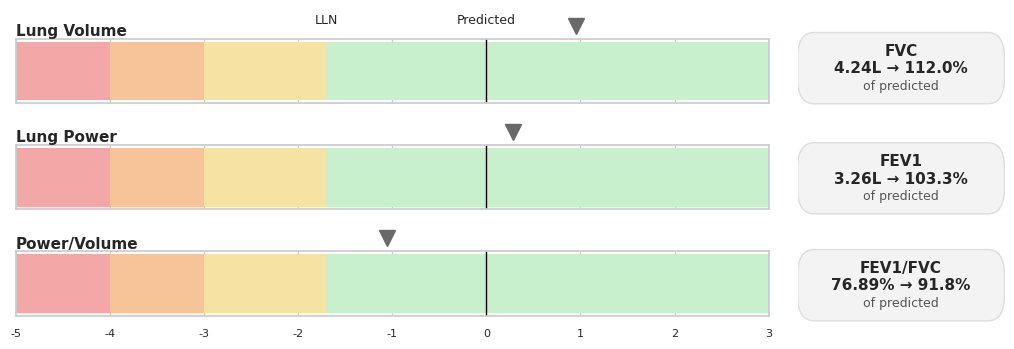

In [17]:
def spirometry_chart():
# Ensure data is loaded

# Coerce numeric columns
    for col in ['Best', 'LLN', 'Pred.', '%Pred.', 'ZScore']:
        if col in spirometry_df.columns:
            spirometry_df[col] = pd.to_numeric(spirometry_df[col], errors='coerce')

# Select rows of interest and prepare display values
    rows_map = {
        'Lung Volume': 'FVC',
        'Lung Power': 'FEV1',
        'Power/Volume': 'FEV1/FVC%'
    }

    records = []
    for label, param in rows_map.items():
        row = spirometry_df.loc[spirometry_df['Parameters'].str.strip() == param]
        if row.empty:
            continue
        row = row.iloc[0]
        records.append({
            'label': label,
            'param': param,
            'best': row['Best'],
            'pct': row['%Pred.'],
            'z': row['ZScore']
        })

# Figure setup
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11.5, 3.6), sharex=True,
                            gridspec_kw={'hspace': 0.65})

    x_min, x_max = -5, 3
# Segment colors: red -> orange -> yellow -> green
    segments = [
        (-5, -4, '#f4a7a7'),   # red-ish
        (-4, -3, '#f7c49a'),   # orange-ish
        (-3, -1.7, '#f6e3a3'),   # yellow-ish
        (-1.7,  3, '#c9f0cc'),   # green-ish
    ]

    ticks = np.arange(x_min, x_max + 1, 1)
    labels = [str(i) for i in ticks]

# Plot each row
    for ax, rec in zip(axes, records):
        # Background segments
        for a, b, color in segments:
            ax.barh(0, width=b-a, left=a, height=0.6, color=color, edgecolor='none')

        # LLN (-1) and Predicted (0) markers
        # ax.axvline(-1, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)

        # Z-score pointer (downward triangle) at top of each panel
        if pd.notna(rec['z']):
            trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
            ax.plot(float(rec['z']), 1.2, marker='v', markersize=12, color='dimgray',
                    transform=trans, clip_on=False)

        # Labels, ticks, and styling
        ax.set_title(rec['label'], loc='left', fontsize=11, fontweight='bold', pad=2)
        ax.set_xlim(x_min, x_max)
        ax.set_yticks([])
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_xlabel('')

# Add x-axis label to the bottom axis
# axes[-1].set_xlabel('Z-score', fontsize=10)

# Top annotations
    axes[0].text(-1.7, 0.45, 'LLN', ha='center', va='bottom', fontsize=9)
    axes[0].text(0, 0.45, 'Predicted', ha='center', va='bottom', fontsize=9)

# Right-side summary boxes
    fig.subplots_adjust(right=0.78)
    box_ax = fig.add_axes([0.805, 0.06, 0.18, 0.90])  # [left, bottom, width, height]
    box_ax.axis('off')

# Helper to draw a pill-shaped text box

    def pill(ax, xy, text):
        x, y = xy
        # Draw rounded rectangle background
        bbox = FancyBboxPatch((x-0.48, y-0.09), 0.96, 0.18,
                            boxstyle='round,pad=0.02,rounding_size=0.08',
                            ec='#dddddd', fc='#f3f3f3', linewidth=1.0)
        ax.add_patch(bbox)
        ax.text(x, y+0.025, text, ha='center', va='center', fontsize=11, fontweight='bold')
        ax.text(x, y-0.055, 'of predicted', ha='center', va='center', fontsize=9, color='#555555')

    box_ax.set_xlim(0, 1)
    box_ax.set_ylim(0, 1)

# Prepare display strings and positions (top to bottom)
    right_items = []
    for rec in records:
        name = 'FVC' if rec['param'] == 'FVC' else ('FEV1' if rec['param'] == 'FEV1' else 'FEV1/FVC')
        unit = 'L' if rec['param'] in ('FVC', 'FEV1') else '%'
        value_fmt = f"{rec['best']:.2f}{unit}"
        pct_fmt = f"{rec['pct']:.1f}%"
        right_items.append((name, value_fmt, pct_fmt))

# Sort to match image order on the right (FVC, FEV1, FEV1/FVC)
    order = ['FVC', 'FEV1', 'FEV1/FVC']
    right_items_sorted = [next(item for item in right_items if item[0] == k) for k in order]

    ys = [0.82, 0.48, 0.15]
    for (name, value_fmt, pct_fmt), y in zip(right_items_sorted, ys):
        main_line = f"{name}\n{value_fmt} → {pct_fmt}"
        pill(box_ax, (0.5, y), main_line)

    plt.savefig('graphs/spirometry_chart.png', dpi=300, bbox_inches='tight')
    plt.show()

spirometry_chart()

In [ ]:
def respiratory_chart():
    df = pnoe_df.copy()
    first_unique_phase = df.drop_duplicates(subset='PHASE')
    phase_times = first_unique_phase['T(sec)'].tolist()

    plt.figure(figsize=(18, 5))
    ax1 = plt.subplot()


# Plot VT with step-like appearance
    line1 = sns.lineplot(data=df, x='T(sec)', y='VT(l)_smoothed', label='VT (L)')
    ax1.set_xlabel('Time (sec)')
    ax1.set_ylabel('VT (L)')
# ax1.set_title('Respiratory')
    ax1.grid(True, alpha=0.1)
    ax1.set_ylim(0, min(8, df['VT(l)_smoothed'].max()))
# Plot speed as step function on secondary y-axis
    ax2 = ax1.twinx()
    ax1.set_xticks(np.arange(0, df['T(sec)'].max() + 200, 200))
    line2 = sns.lineplot(data=df, x='T(sec)', y='Speed', color='green', ax=ax2, 
                drawstyle='steps-post', linewidth=2, label='Speed')
    ax2.set_ylabel('Speed')
    ax2.set_ylim(0, min(30, df['Speed'].max()) + 1)

# Remove default legends first
    ax1.get_legend().remove()
    ax2.get_legend().remove()

# Combine legends from both axes in the top left
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add colored background regions if you have phase information
    ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
    ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
    ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
    ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

    plt.savefig('graphs/respiratory.png', dpi=300, bbox_inches='tight')
    plt.show()

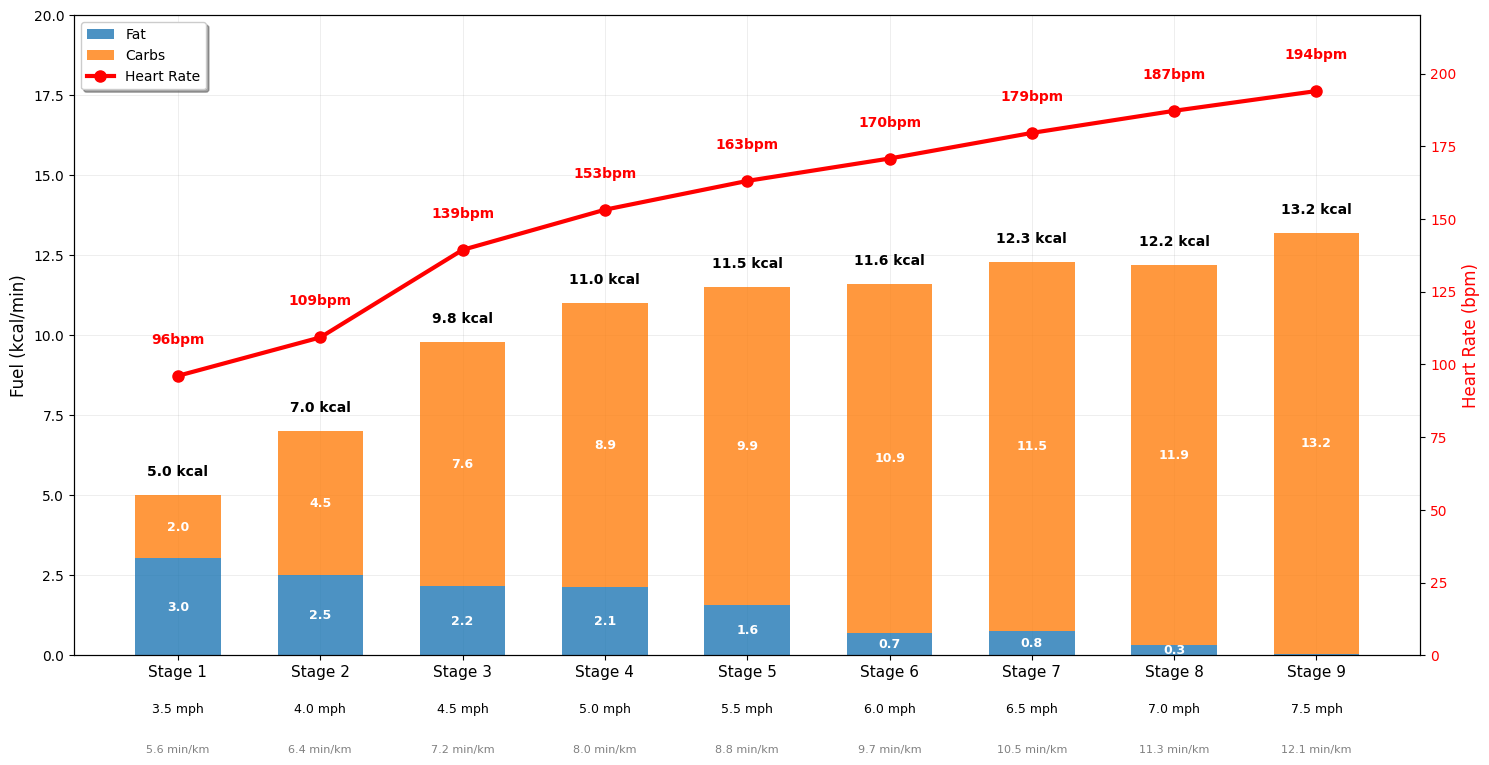

In [21]:
def fuel_utilization_chart():
        
# Group by speed and calculate mean for numeric columns only
    speed_groups = pnoe_df.groupby('Speed').mean(numeric_only=True).round(1)

# Drop the first and last row from speed_groups
    speed_groups = speed_groups.iloc[1:-1]

# Filter data to only include speeds in the desired range
    filtered_data = speed_groups[(speed_groups.index >= 3.5) & (speed_groups.index <= 7.5)]

# Create figure with specific size
    plt.figure(figsize=(15, 8))
    plt.style.use('default')

# Create stage labels and positions
    stage_labels = [f'Stage {i}' for i in range(1, len(filtered_data) + 1)]
    x_positions = np.arange(len(filtered_data))

# Calculate fat and carbs energy expenditure from percentages
    fat_ee = filtered_data['EE(kcal/min)'] * filtered_data['FAT(%)'] / 100
    carbs_ee = filtered_data['EE(kcal/min)'] * filtered_data['CARBS(%)'] / 100

# Create the main axis for the stacked bars
    ax1 = plt.gca()

# Create stacked bar chart with colors
    bars_fat = ax1.bar(x_positions, fat_ee, color='#1f77b4', alpha=0.8, width=0.6, label='Fat')
    bars_carbs = ax1.bar(x_positions, carbs_ee, bottom=fat_ee, color='#ff7f0e', alpha=0.8, width=0.6, label='Carbs')

# Set labels and formatting for primary axis
    ax1.set_xlabel('', fontsize=12)
    ax1.set_ylabel('Fuel (kcal/min)', fontsize=12)
    ax1.set_ylim(0, 20)

# Add individual values on each bar segment
    for i, (fat_val, carb_val, total_val) in enumerate(zip(fat_ee, carbs_ee, filtered_data['EE(kcal/min)'])):
        if fat_val > 0.3:  # Fat value
            ax1.text(i, fat_val/2, f'{fat_val:.1f}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        if carb_val > 0.3:  # Carbs value
            ax1.text(i, fat_val + carb_val/2, f'{carb_val:.1f}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white')
        # Total EE
        ax1.text(i, total_val + 0.5, f'{total_val:.1f} kcal', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black')

# Add speed labels below x-axis
    for i, speed in enumerate(filtered_data.index):
        ax1.text(i, -1.5, f'{speed:.1f} mph', ha='center', va='top', fontsize=9)
        ax1.text(i, -2.8, f'{speed*1.609:.1f} min/km', ha='center', va='top', fontsize=8, color='gray')

# Create secondary y-axis for heart rate
    ax2 = ax1.twinx()

# Plot heart rate line (no manual offset)
    hr_line = ax2.plot(x_positions, filtered_data['HR(bpm)'],
                    marker='o', linewidth=3, markersize=8, color='red', label='Heart Rate')

# Set heart rate axis formatting
    ax2.set_ylabel('Heart Rate (bpm)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

# Dynamically adjust HR axis to float above bars
    max_bar_height = max(filtered_data['EE(kcal/min)'])
    ax2.set_ylim(0, 220)  # ensures HR line is above bars


# Add HR values above the points
    for i, hr in enumerate(filtered_data['HR(bpm)']):
        ax2.text(i, hr + 10, f'{int(hr)}bpm', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='red')

# Set x-axis formatting
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(stage_labels, fontsize=11)

# Add title
# plt.suptitle('Fuel Utilization Report - Institute of Science, Health and Performance',
#              fontsize=14, fontweight='bold', y=0.95)

# Create legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
            frameon=True, fancybox=True, shadow=True)

# Add grid
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)

# Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, top=0.9)
    plt.savefig('graphs/fuel_utilization_chart.png', dpi=300)
    plt.show()

fuel_utilization_chart()
